<a href="https://colab.research.google.com/github/jasper99tai77-afk/BAPortfolio/blob/main/Portfolio_Bankrupcy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/JaperTai77/data-modified/main/data.csv")
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


# Data Preprocessing

#### Remove unuseful features

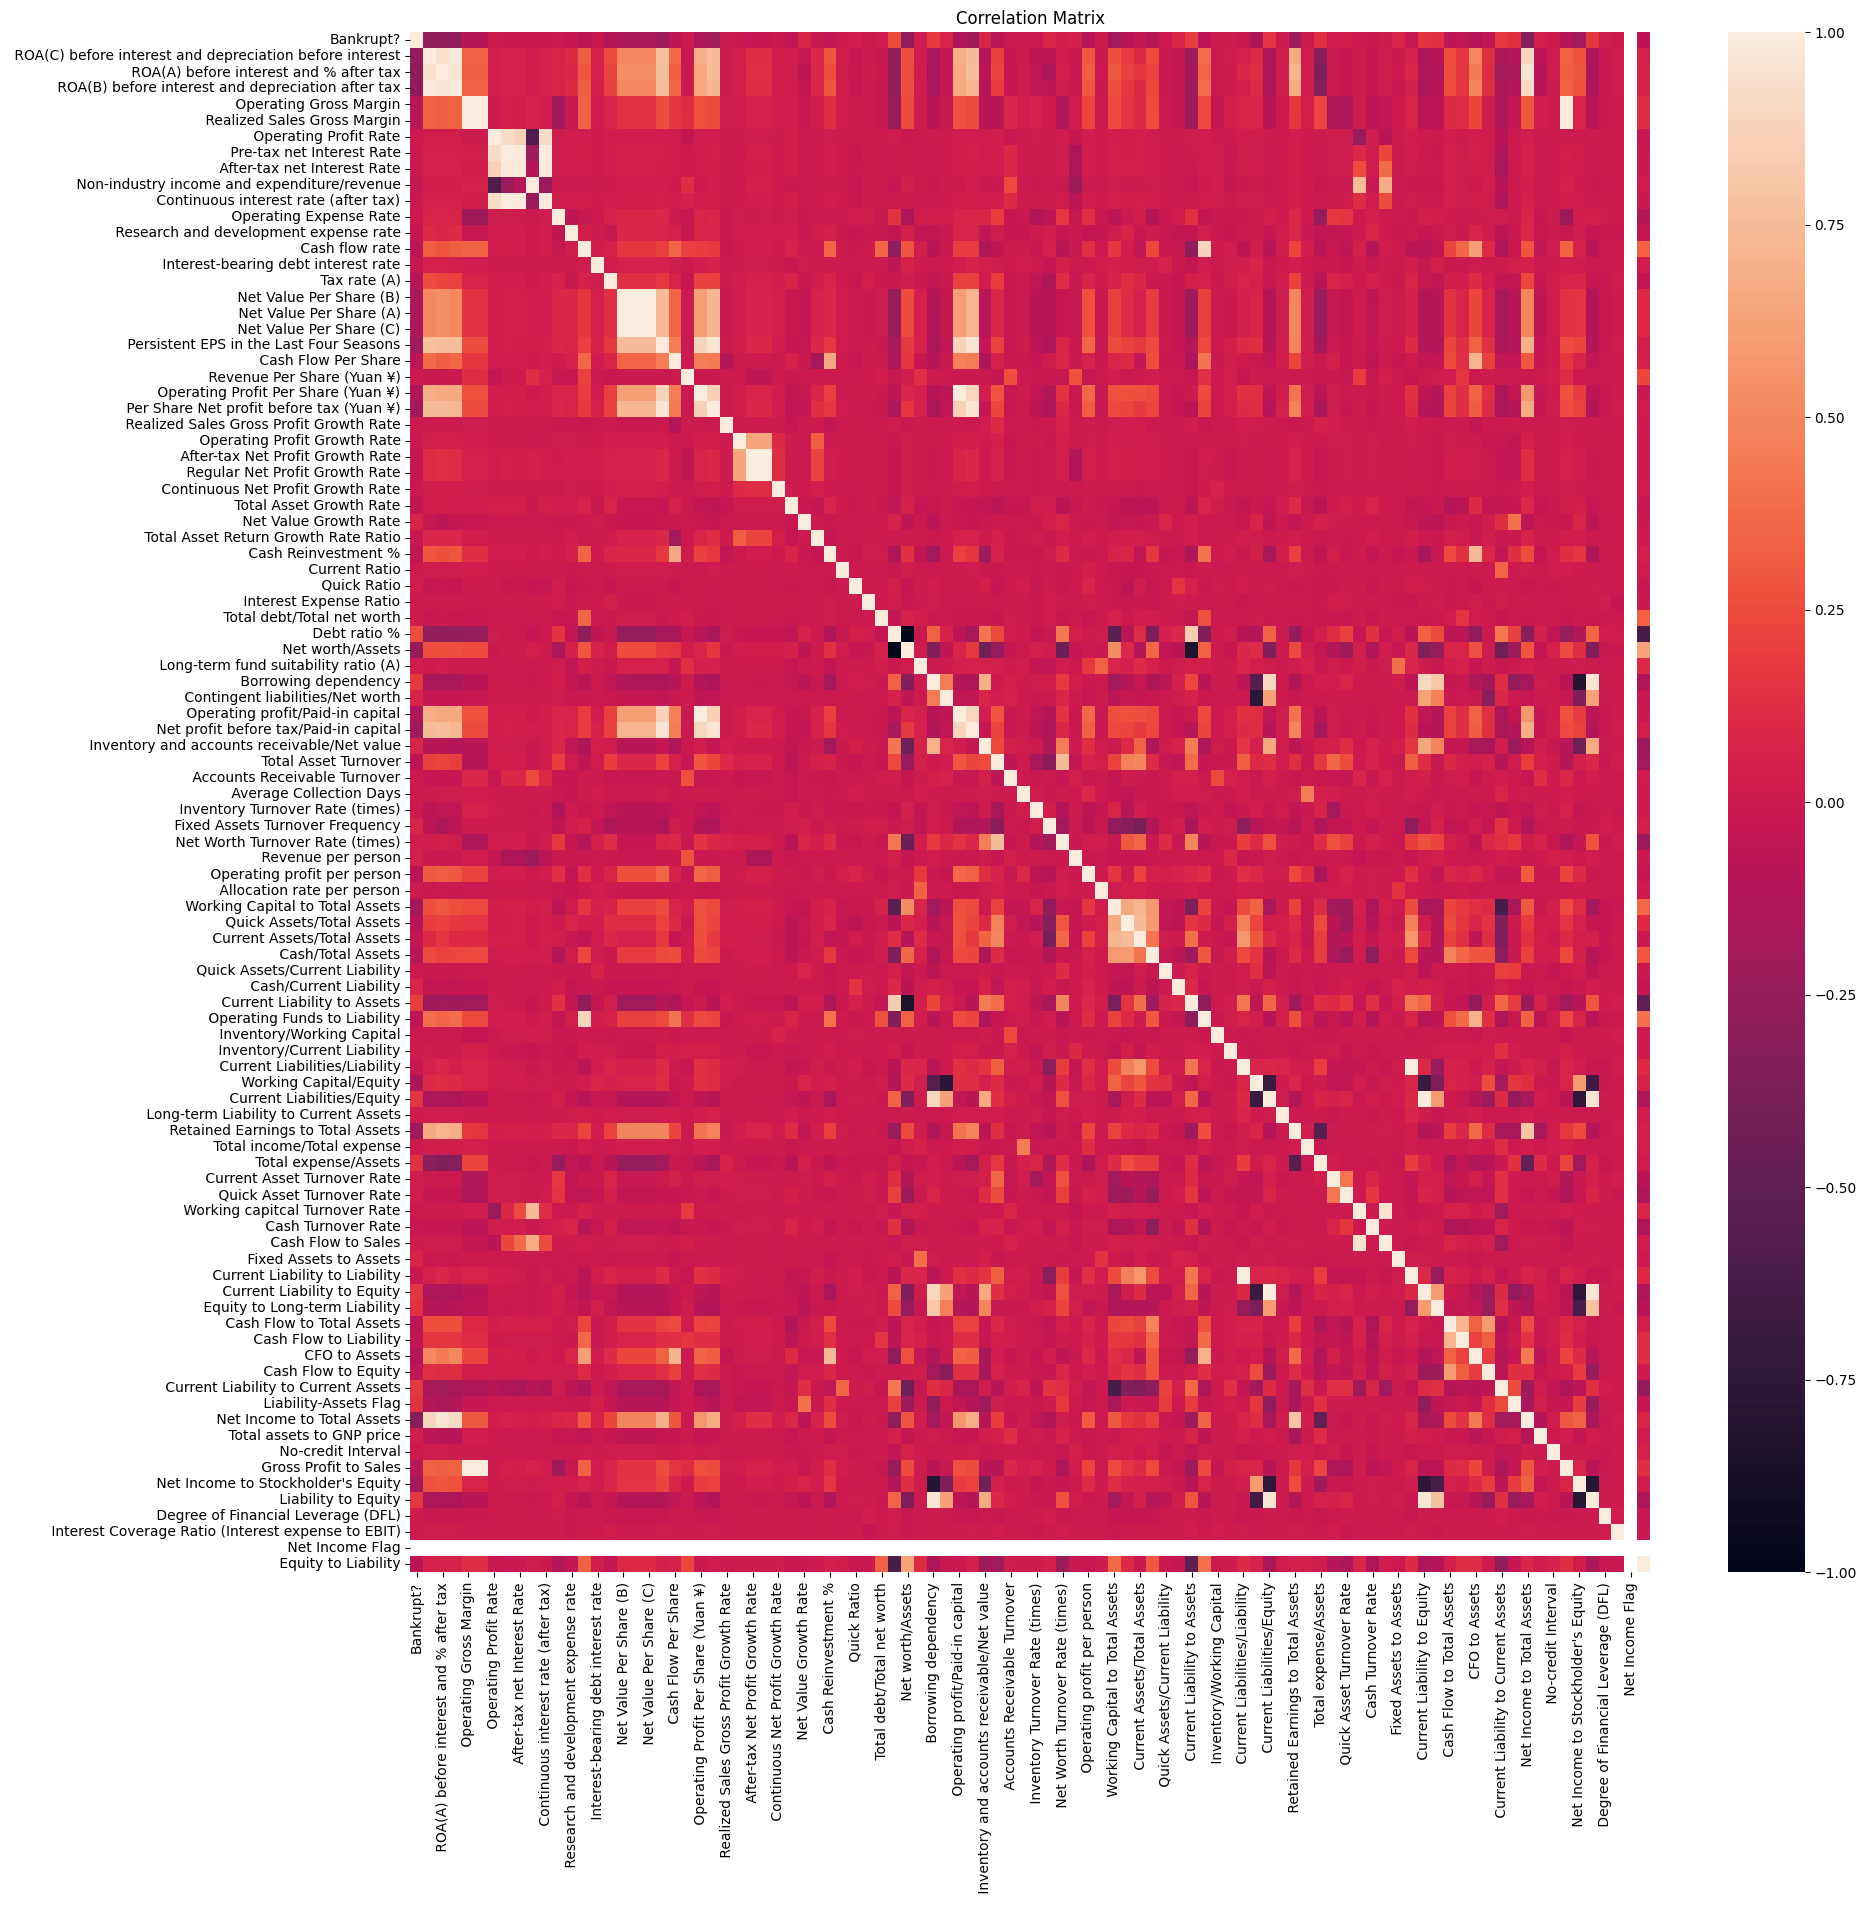

In [3]:
# View Correlation
plt.figure(figsize = (20,20))
sns.heatmap(df.corr()).set_title('Correlation Matrix')
plt.show()

We will observe and remove the highly correlated columns to avoid potential training issues.

In [3]:
# View columns with high correlation (0.9, -0.9).
corr_m = df.corr().abs()
upper_tri = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))

upper_tri.unstack().dropna()
corr_pairs = upper_tri.unstack().dropna()
high_corr_pairs = corr_pairs[abs(corr_pairs) > 0.9].sort_values(ascending=False)
print(high_corr_pairs)

Current Liability to Equity                        Current Liabilities/Equity                                 1.000000
Current Liability to Liability                     Current Liabilities/Liability                              1.000000
Net worth/Assets                                   Debt ratio %                                               1.000000
Gross Profit to Sales                              Operating Gross Margin                                     1.000000
Net Value Per Share (C)                            Net Value Per Share (A)                                    0.999837
Realized Sales Gross Margin                        Operating Gross Margin                                     0.999518
Gross Profit to Sales                              Realized Sales Gross Margin                                0.999518
Net Value Per Share (A)                            Net Value Per Share (B)                                    0.999342
Net Value Per Share (C)                         

In [4]:
# Filter out column with high correlation (0.9, -0.9).
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
df_filtered = df.drop(columns=to_drop)

#### Deal with imbalance

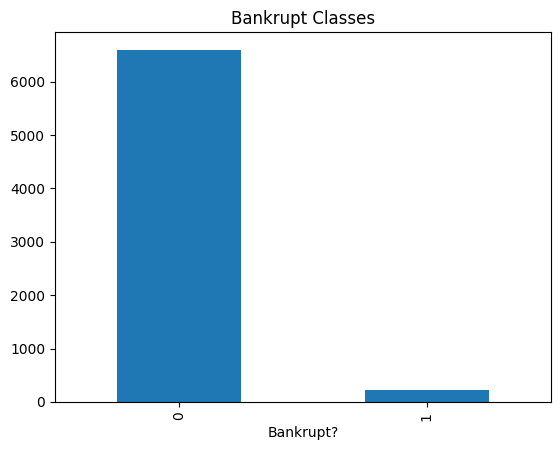

In [8]:
# Frequency of each class
df['Bankrupt?'].value_counts().plot(kind='bar').set_title('Bankrupt Classes');

Our dataset has a major class imbalance because it contains thousands of companies that have not gone bankrupt but only a very small number of bankrupt ones. To fix this, we use a technique called SMOTE to generate artificial examples of bankrupt companies in our training data.

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [6]:
# Split data to train test
X = df_filtered.drop('Bankrupt?', axis=1)
y = df_filtered['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

In [7]:
# Perform SMOTE
smote = SMOTE(random_state=7)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

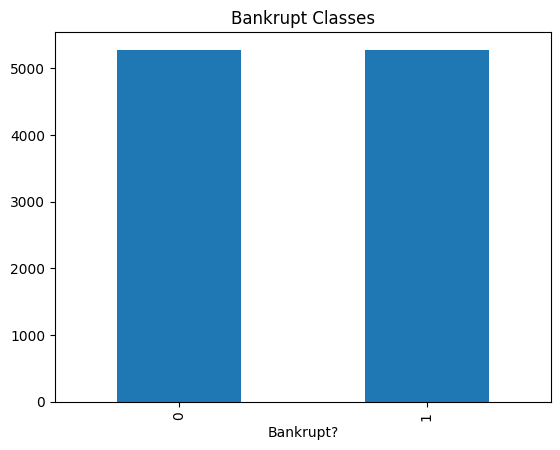

In [8]:
y_train_resampled.value_counts().plot(kind='bar').set_title('Bankrupt Classes');

After resampling. Our training data has an equal number of both class.

### Scale data

In [9]:
# Scale the dataset
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

# Modeling

In [10]:
from sklearn import metrics
import itertools

def plot_confusion_matrix(y_test, y_pred_class, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints metrics and plots the confusion matrix.
    """
    print("Accuracy: ", metrics.accuracy_score(y_test, y_pred_class))
    print("Recall:",metrics.recall_score(y_test, y_pred_class))
    print("F1 score:",metrics.f1_score(y_test, y_pred_class))
    cm = metrics.confusion_matrix(y_test, y_pred_class)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label',fontsize=15)
    plt.xlabel('Predicted label',fontsize=15)
    plt.show()

#### Logistic regression

Accuracy:  0.874633431085044
Recall: 0.7272727272727273
F1 score: 0.2723404255319149


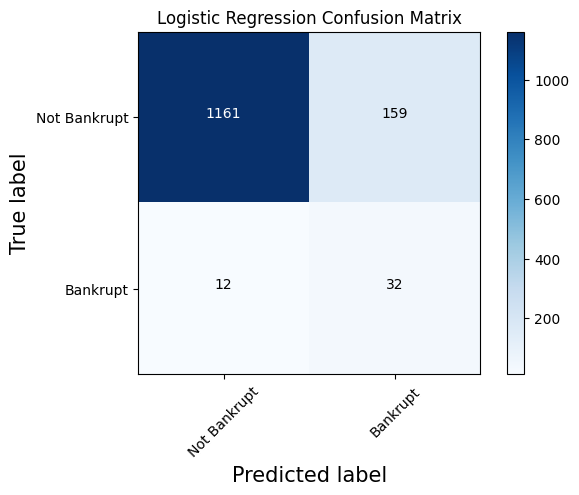

In [43]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=7)
model_log.fit(X_train_resampled, y_train_resampled)

# Evaluate model
y_pred_class = model_log.predict(X_test)
plot_confusion_matrix(y_test, y_pred_class, classes=['Not Bankrupt', 'Bankrupt'], title='Logistic Regression Confusion Matrix')

Logistic Regression model catched about 73% of the companies that actually went bankrupt with an accuracy of 87%. For our scenario, we are okay with some false positve because it's much better to be extra cautious than to miss a company that's about to go under.

#### K-nearest Neighbors Classification

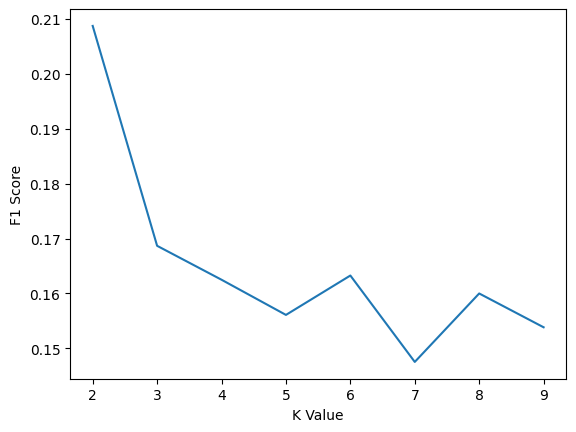

In [44]:
# Find best k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

score = []
for i in range(2, 10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_resampled, y_train_resampled)
    ypred = knn.predict(X_test)

    score.append(f1_score(y_test, ypred))

plt.plot(range(2, 10), score)
plt.xticks(np.arange(2, 10, 1))
plt.xlabel("K Value")
plt.ylabel("F1 Score")
plt.show()

Accuracy:  0.8387096774193549
Recall: 0.45454545454545453
F1 score: 0.15384615384615385


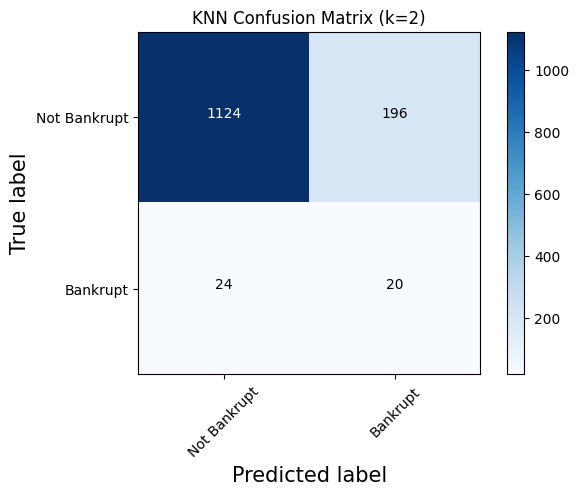

In [45]:
# Train and evaluate KNN model
model_knn = KNeighborsClassifier(n_neighbors=2)
model_knn.fit(X_train_resampled, y_train_resampled)
y_pred = knn.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['Not Bankrupt', 'Bankrupt'], title='KNN Confusion Matrix (k=2)')

The KNN model caught about 45% of the bankrupt companies, which is slightly lower compared to the Logistic Regression. While we are still seeing plenty of false alarms, the bigger issue here is that more bankrupt companies are unnoticed. Therefore, this model probably won't be our final choice.

#### Supportive Vector Machine

In [48]:
# Run a grid search to find optimal parameter
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, scoring='recall', cv=2)
grid.fit(X_train_resampled, y_train_resampled)
print(f"Best SVM Parameters: {grid.best_params_}")

Fitting 2 folds for each of 36 candidates, totalling 72 fits
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   2.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   2.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   8.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   6.2s
[CV] END ......................C=0.1, gamma=0.1, kernel=poly; total time=   4.8s
[CV] END ......................C=0.1, gamma=0.1, kernel=poly; total time=   4.6s
[CV] END ...................C=0.1, gamma=0.1, kernel=sigmoid; total time=  12.1s
[CV] END ...................C=0.1, gamma=0.1, kernel=sigmoid; total time=   6.9s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   1.6s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   2.2s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   2.4s
[CV] END .........................C=0.1, gamma=1

Accuracy:  0.9420821114369502
Recall: 0.3409090909090909
F1 score: 0.27522935779816515


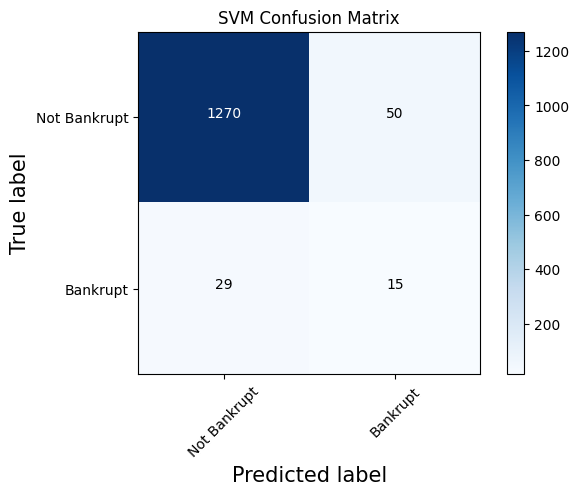

In [49]:
# Evaluate model
y_pred = grid.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['Not Bankrupt', 'Bankrupt'], title='SVM Confusion Matrix')

The SVM model shows high precision. However, it flagged 50 healthy companies as risky, but missed 29 out of the 44 actual bankruptcies, leading to a lower Recall. Since we'd rather flag potential risks, this model might be too conservative.

#### Naive Bayes Classifier

Accuracy:  0.4809384164222874
Recall: 0.8636363636363636
F1 score: 0.09693877551020408


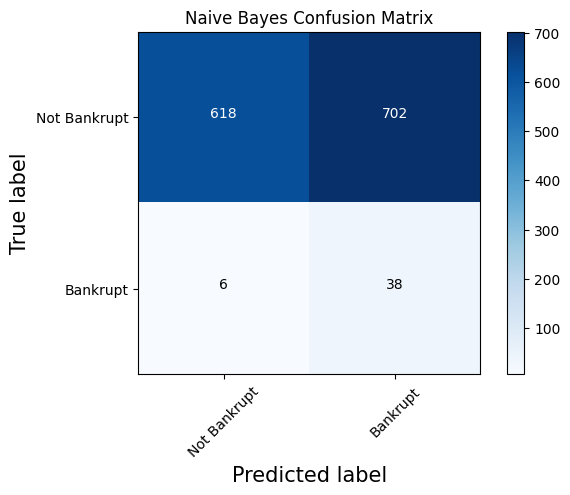

In [50]:
# Train on Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(X_train_resampled, y_train_resampled)

# Evaluate model
y_pred = model_nb.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['Not Bankrupt', 'Bankrupt'], title='Naive Bayes Confusion Matrix')

The Naive Bayes model achieved our highest Recall at 86%, correctly identifying 38 out of 44 actual bankruptcies. However, this came at a significant cost. It flagged 702 healthy companies as risky, which is nearly half of the non-bankrupt test set. Although we are able to tolerate false positive to avoid missing a bankruptcy, this specific trade-off is too extreme for our business model.

### Decision Tree

In [51]:
# Run a grid search to find optimal parameter
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [5, 10, 20, 50],
    'min_samples_leaf': [2, 5, 10],
    'max_leaf_nodes': [10, 20, 50, 100]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, refit=True, verbose=2, scoring='recall', cv=2)
grid_dt.fit(X_train_resampled, y_train_resampled)
print(f"Best Decision Tree Parameters: {grid_dt.best_params_}")

Fitting 2 folds for each of 48 candidates, totalling 96 fits
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=2; total time=   0.3s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=2; total time=   0.3s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=5; total time=   0.3s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=5; total time=   0.3s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=10; total time=   0.3s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=10; total time=   0.3s
[CV] END .max_depth=5, max_leaf_nodes=20, min_samples_leaf=2; total time=   0.3s
[CV] END .max_depth=5, max_leaf_nodes=20, min_samples_leaf=2; total time=   0.4s
[CV] END .max_depth=5, max_leaf_nodes=20, min_samples_leaf=5; total time=   0.4s
[CV] END .max_depth=5, max_leaf_nodes=20, min_samples_leaf=5; total time=   0.3s
[CV] END max_depth=5, max_leaf_nodes=20, min_samples_leaf=10; total time=   0.4s
[CV] END max_depth=5, max_leaf_nodes=20, min_sam

Accuracy:  0.907624633431085
Recall: 0.5
F1 score: 0.25882352941176473


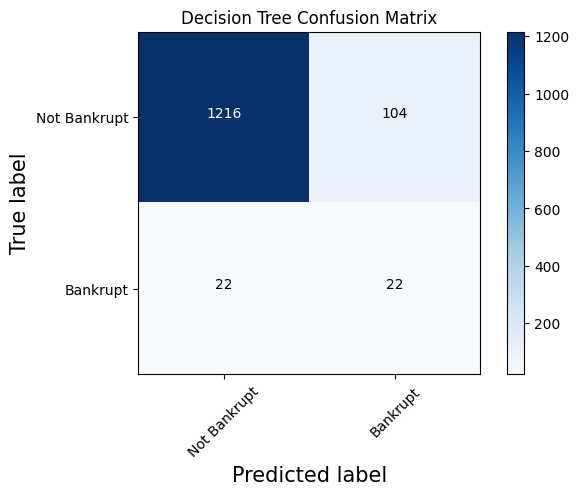

In [53]:
# Evaluate model
y_pred = grid_dt.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['Not Bankrupt', 'Bankrupt'], title='Decision Tree Confusion Matrix')

The Decision Tree model correctly identified 50% of the bankrupt companies. While it is better at catching risks than SVM or KNN, it still misses half of the actual bankruptcy cases, making it less effective than Logistic Regression.

#### Random Forest

In [54]:
# Run a grid search to find optimal parameter
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 20, 50],
    'min_samples_leaf': [2, 5, 10],
    'max_leaf_nodes': [10, 20, 50, 100]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, refit=True, verbose=2, scoring='recall', cv=2)
grid_rf.fit(X_train_resampled, y_train_resampled)
print(f"Best Random Forest Parameters: {grid_rf.best_params_}")

Fitting 2 folds for each of 144 candidates, totalling 288 fits
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=10; total time=   0.2s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=10; total time=   0.2s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=50; total time=   1.2s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=50; total time=   2.4s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=100; total time=   3.5s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=100; total time=   3.5s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=5, n_estimators=10; total time=   0.3s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=5, n_estimators=10; total time=   0.3s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=5, n_estimators=50; total time=   1.5s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=5, n

Accuracy:  0.9288856304985337
Recall: 0.5227272727272727
F1 score: 0.32167832167832167


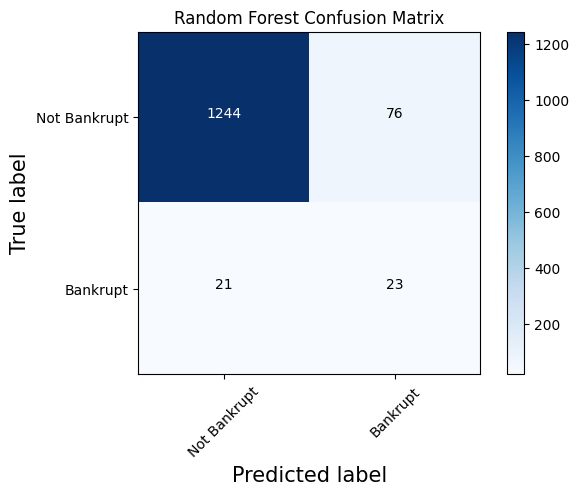

In [55]:
# Evaluate model
y_pred = grid_rf.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['Not Bankrupt', 'Bankrupt'], title='Random Forest Confusion Matrix')

The Random Forest model correctly identified about 52% of bankruptcies. It didn't flag as many false positive as some other models, but it do produce a higher F1 score. Overall, this model has a more conservative approach.

#### XGBoost

Accuracy:  0.9552785923753666
Recall: 0.45454545454545453
F1 score: 0.39603960396039606


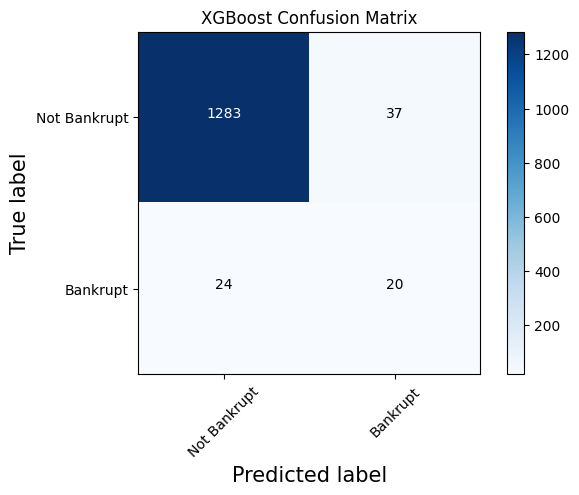

In [57]:
# Train model with XGBoost
from xgboost import XGBClassifier

model_xgb = XGBClassifier(eval_metric='logloss')
model_xgb.fit(X_train_resampled, y_train_resampled)


# Evaluate model
y_pred = model_xgb.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['Not Bankrupt', 'Bankrupt'], title='XGBoost Confusion Matrix')


The XGBoost model is more conservative than the Random Forest, correctly identifying about 45% of the bankrupt companies.

#### Neural Network

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping

model_nn = Sequential()

input_dimension = X_train_resampled.shape[1]

model_nn.add(Dense(64, input_dim=input_dimension))
model_nn.add(BatchNormalization())
model_nn.add(Activation('relu'))
model_nn.add(Dropout(0.3))

model_nn.add(Dense(32))
model_nn.add(BatchNormalization())
model_nn.add(Activation('relu'))
model_nn.add(Dropout(0.2))

model_nn.add(Dense(16))
model_nn.add(BatchNormalization())
model_nn.add(Activation('relu'))
model_nn.add(Dropout(0.2))
model_nn.add(Dense(1, activation='sigmoid'))

model_nn.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc')
    ]
)

earstop = EarlyStopping(
    monitor='val_recall',
    mode='max',
    verbose=1,
    patience=10,
    restore_best_weights=True
)

history = model_nn.fit(
    x=X_train_resampled,
    y=y_train_resampled,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[earstop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.5904 - pr_auc: 0.7319 - recall: 0.6326 - val_loss: 0.1242 - val_pr_auc: 0.2393 - val_recall: 0.0000e+00
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3308 - pr_auc: 0.9182 - recall: 0.9090 - val_loss: 0.1498 - val_pr_auc: 0.2502 - val_recall: 0.3864
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2487 - pr_auc: 0.9505 - recall: 0.9350 - val_loss: 0.2483 - val_pr_auc: 0.2514 - val_recall: 0.6818
Epoch 4/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2345 - pr_auc: 0.9487 - recall: 0.9438 - val_loss: 0.2485 - val_pr_auc: 0.2475 - val_recall: 0.7045
Epoch 5/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2094 - pr_auc: 0.9598 - recall: 0.9354 - val_loss: 0.4492 - val_pr_auc: 0.2203 - val_recall: 0.7727
Epoch 6/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1976 - pr_auc: 0.9626 - recall: 0.9489 - val_loss: 0.2451 - val_pr_auc: 0.2179 - val_recall: 0.5909
Epoch 7/100
165/

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Accuracy:  0.8027859237536656
Recall: 0.7727272727272727
F1 score: 0.20178041543026706


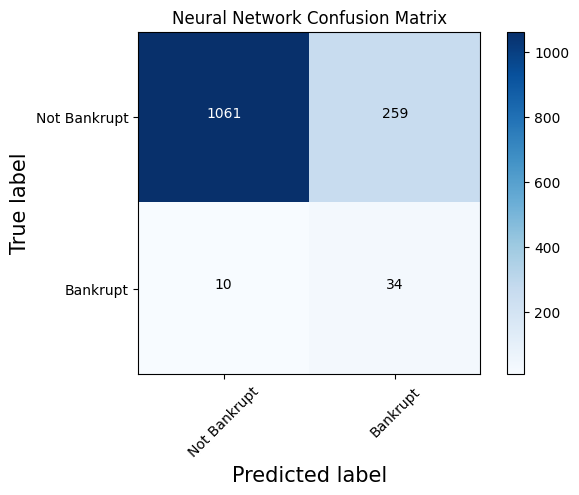

In [16]:
# Evaluate model
y_pred = model_nn.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
plot_confusion_matrix(y_test, y_pred, classes=['Not Bankrupt', 'Bankrupt'], title='Neural Network Confusion Matrix')

The Neural Network outperformed most of the models in identifying actual risk, achieving a recall of 77%. While this led to 259 false alarms, we are happy with this trade-off because catching nearly 4 out of 5 failing companies provides a much stronger safety net.

# Summary

The Neural Network was the best performer because it caught 77% of bankruptcies, providing the strongest safety net for catching risk. XGBoost took a more conservative approach, producing the fewest false positive but unfortunately missing more than half of the actual bankruptcy cases. We ultimately prioritized catching as many failures as possible to ensure no critical risks were ignored.